In [1]:
import os
import shutil
import zipfile
from pathlib import Path
from collections import defaultdict
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ---------------------------------------------------
# INPUT DATASET (contains Train/Test/Val ZIP folders)
# ---------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/OUR_DATASET/Dataset"

# ---------------------------------------------------
# OUTPUT DATASET
# ---------------------------------------------------

OUTPUT_PATH =  "/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1"

# ---------------------------------------------------
# TEMP EXTRACTION FOLDER
# ---------------------------------------------------

TEMP_PATH = "/content/temp_extract"



print("Dataset Path : ", DATASET_PATH)
print("Output Path  : ", OUTPUT_PATH)
print("Temp Path    : ", TEMP_PATH)

Dataset Path :  /content/drive/MyDrive/OUR_DATASET/Dataset
Output Path  :  /content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1
Temp Path    :  /content/temp_extract


In [4]:
print(DATASET_PATH)
print()

print(os.listdir(DATASET_PATH))

/content/drive/MyDrive/OUR_DATASET/Dataset

['Train', 'Test', 'Val']


In [21]:
# ==========================================================
# Universal Dataset Builder V1
# Cell 3 - Configuration
# ==========================================================

# ----------------------------------------------------------
# ZIP FILE -> OUTPUT CLASS
# ----------------------------------------------------------

ZIP_TO_CLASS = {

    "Abuse.zip": "Abuse",
    "Burglary.zip": "Burglary",
    "Fighting.zip": "Fighting",
    "Accident.zip": "RoadAccident",
    "Snatching.zip": "Snatching",
    "Normal.zip": "Normal"

}

# ----------------------------------------------------------
# INPUT SPLIT -> OUTPUT SPLIT
# ----------------------------------------------------------

SPLIT_MAPPING = {

    "Train": "Train",
    "Val": "Validation",
    "Test": "Test"

}

# ----------------------------------------------------------
# IMAGE TYPES
# ----------------------------------------------------------

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

# ----------------------------------------------------------
# SPECIAL RULES
# Skip these folders while processing the ZIP
# ----------------------------------------------------------

SKIP_FOLDERS = {

    "Accident.zip": [
        "normal",
        "normal img"
    ]

}

# ----------------------------------------------------------
# BUILD OPTIONS
# ----------------------------------------------------------

REBUILD_DATASET = True      # Delete existing output dataset and rebuild

DRY_RUN = False         # Change to False when ready to build

VERBOSE = True          # Print progress

OVERWRITE = False       # Never overwrite existing files

In [6]:
print("Classes:")

for zip_file, class_name in ZIP_TO_CLASS.items():
    print(f"{zip_file:15} --> {class_name}")

print("\nSpecial Rules:")
print(SKIP_FOLDERS)

print("\nDry Run :", DRY_RUN)

Classes:
Abuse.zip       --> Abuse
Burglary.zip    --> Burglary
Fighting.zip    --> Fighting
Accident.zip    --> RoadAccident
Snatching.zip   --> Snatching
Normal.zip      --> Normal

Special Rules:
{'Accident.zip': ['normal', 'normal img']}

Dry Run : True


In [7]:
CLASS_MAPPING = {

    "abuse": "Abuse",

    "burglary": "Burglary",

    "fight": "Fighting",
    "fighting": "Fighting",

    "accident": "RoadAccident",
    "accident img": "RoadAccident",

    "snatching": "Snatching",
    "santching": "Snatching",   # teammate typo

    "normal": "Normal",
    "normal img": "Normal"
}

In [8]:
# Only this ZIP contributes Normal images

NORMAL_SOURCE_ZIP = "Normal.zip"

In [9]:
# ==========================================================
# Universal Dataset Builder V1
# Cell 4 - Helper Functions
# ==========================================================

def is_image(filename):
    """
    Returns True if the file is an image.
    """
    return filename.lower().endswith(IMAGE_EXTENSIONS)


def create_output_folders():
    """
    Creates a fresh output dataset.
    Deletes the existing dataset if REBUILD_DATASET=True.
    """

    # Delete existing dataset
    if os.path.exists(OUTPUT_PATH):

        if REBUILD_DATASET:

            print("Deleting existing output dataset...")
            shutil.rmtree(OUTPUT_PATH)

        else:

            print("Using existing output dataset...")

    # Create folder structure

    os.makedirs(OUTPUT_PATH, exist_ok=True)

    for split in SPLIT_MAPPING.values():

        split_path = os.path.join(OUTPUT_PATH, split)
        os.makedirs(split_path, exist_ok=True)

        for class_name in ZIP_TO_CLASS.values():

            class_path = os.path.join(split_path, class_name)
            os.makedirs(class_path, exist_ok=True)

    print("Output folder structure ready.")


def extract_zip(zip_path):
    """
    Extract one ZIP into the temporary folder.
    """

    if os.path.exists(TEMP_PATH):
        shutil.rmtree(TEMP_PATH)

    os.makedirs(TEMP_PATH, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(TEMP_PATH)


def cleanup_temp():
    """
    Delete temporary extraction folder.
    """

    if os.path.exists(TEMP_PATH):
        shutil.rmtree(TEMP_PATH)


def get_unique_filename(destination_folder, filename):
    """
    Preserve original filename.
    Rename only if duplicate exists.
    """

    base, extension = os.path.splitext(filename)

    candidate = filename
    counter = 1

    while os.path.exists(os.path.join(destination_folder, candidate)):

        candidate = f"{base}_{counter}{extension}"
        counter += 1

    return candidate

In [10]:
#Testing----------------

create_output_folders()

print("\nFolder structure created successfully.\n")

for split in SPLIT_MAPPING.values():

    print(split)

    split_path = os.path.join(OUTPUT_PATH, split)

    print(sorted(os.listdir(split_path)))

    print()

Deleting existing output dataset...
Output folder structure ready.

Folder structure created successfully.

Train
['Abuse', 'Burglary', 'Fighting', 'Normal', 'RoadAccident', 'Snatching']

Validation
['Abuse', 'Burglary', 'Fighting', 'Normal', 'RoadAccident', 'Snatching']

Test
['Abuse', 'Burglary', 'Fighting', 'Normal', 'RoadAccident', 'Snatching']



In [11]:
# ==========================================================
# Universal Dataset Builder V1
# Cell 5 - Process One ZIP
# ==========================================================

def process_zip(zip_path, output_split):

    zip_name = os.path.basename(zip_path)

    # ------------------------------------------------------
    # Check if ZIP is recognised
    # ------------------------------------------------------

    if zip_name not in ZIP_TO_CLASS:

        print(f"Skipping unknown ZIP : {zip_name}")
        return 0

    class_name = ZIP_TO_CLASS[zip_name]

    if VERBOSE:
        print(f"\nProcessing : {zip_name}")
        print(f"Class      : {class_name}")

    # ------------------------------------------------------
    # Extract ZIP
    # ------------------------------------------------------

    extract_zip(zip_path)

    destination_folder = os.path.join(
        OUTPUT_PATH,
        output_split,
        class_name
    )

    copied = 0
    skipped = 0

    # ------------------------------------------------------
    # Walk through extracted files
    # ------------------------------------------------------

    for root, dirs, files in os.walk(TEMP_PATH):

        folder_name = os.path.basename(root).lower().strip()

        # ----------------------------------------------
        # Skip unwanted folders
        # ----------------------------------------------

        if zip_name in SKIP_FOLDERS:

            if folder_name in SKIP_FOLDERS[zip_name]:

                skipped += len([f for f in files if is_image(f)])
                continue

        # ----------------------------------------------
        # Process image files
        # ----------------------------------------------

        for file in files:

            if not is_image(file):
                continue

            source_file = os.path.join(root, file)

            destination_name = get_unique_filename(
                destination_folder,
                file
            )

            destination_file = os.path.join(
                destination_folder,
                destination_name
            )

            if not DRY_RUN:

                shutil.copy2(
                    source_file,
                    destination_file
                )

            copied += 1

    cleanup_temp()

    if VERBOSE:

        print(f"Copied  : {copied}")

        if skipped > 0:
            print(f"Skipped : {skipped}")

    return copied

In [12]:
##Testing-----------------------------


# ==========================================================
# TEST - Process One ZIP
# ==========================================================

create_output_folders()

train_folder = os.path.join(DATASET_PATH, "Train")

zip_files = sorted(
    [f for f in os.listdir(train_folder)
     if f.endswith(".zip")]
)

print(zip_files)

Deleting existing output dataset...
Output folder structure ready.
['Abuse.zip', 'Accident.zip', 'Burglary.zip', 'Fighting.zip', 'Normal.zip', 'Snatching.zip']


In [13]:
# Test only one ZIP

process_zip(
    os.path.join(train_folder, "Abuse.zip"),
    "Train"
)


Processing : Abuse.zip
Class      : Abuse
Copied  : 1119


1119

In [14]:
# ==========================================================
# Universal Dataset Builder V1
# Cell 6 - Build Complete Dataset
# ==========================================================

def build_dataset():

    create_output_folders()

    summary = defaultdict(dict)

    for input_split, output_split in SPLIT_MAPPING.items():

        print("\n" + "=" * 60)
        print(f"Processing {input_split}")
        print("=" * 60)

        split_folder = os.path.join(DATASET_PATH, input_split)

        zip_files = sorted([
            f for f in os.listdir(split_folder)
            if f.lower().endswith(".zip")
        ])

        print(f"Found {len(zip_files)} ZIP files\n")

        total_images = 0

        for index, zip_file in enumerate(zip_files, start=1):

            print(f"[{index}/{len(zip_files)}] {zip_file}")

            copied = process_zip(
                os.path.join(split_folder, zip_file),
                output_split
            )

            class_name = ZIP_TO_CLASS.get(zip_file, "Unknown")
            summary[output_split][class_name] = copied

            total_images += copied

        print(f"\nCompleted {output_split}")
        print(f"Total Images : {total_images}")

    return summary

In [27]:
summary = build_dataset()

Output folder structure ready.

Processing Train
Found 6 ZIP files

[1/6] Abuse.zip

Processing : Abuse.zip
Class      : Abuse
Copied  : 1119
[2/6] Accident.zip

Processing : Accident.zip
Class      : RoadAccident
Copied  : 146
Skipped : 1563
[3/6] Burglary.zip

Processing : Burglary.zip
Class      : Burglary
Copied  : 856
[4/6] Fighting.zip

Processing : Fighting.zip
Class      : Fighting
Copied  : 427
[5/6] Normal.zip

Processing : Normal.zip
Class      : Normal
Copied  : 1563
[6/6] Snatching.zip

Processing : Snatching.zip
Class      : Snatching
Copied  : 3708

Completed Train
Total Images : 7819

Processing Val
Found 6 ZIP files

[1/6] Abuse.zip

Processing : Abuse.zip
Class      : Abuse
Copied  : 382
[2/6] Accident.zip

Processing : Accident.zip
Class      : RoadAccident
Copied  : 98
Skipped : 768
[3/6] Burglary.zip

Processing : Burglary.zip
Class      : Burglary
Copied  : 250
[4/6] Fighting.zip

Processing : Fighting.zip
Class      : Fighting
Copied  : 159
[5/6] Normal.zip

Proc

In [16]:
# ==========================================================
# Universal Dataset Builder V1
# Cell 7 - Dataset Summary
# ==========================================================

def print_dataset_summary(summary):

    print("\n")
    print("=" * 70)
    print("FINAL DATASET SUMMARY")
    print("=" * 70)

    grand_total = 0

    for split in ["Train", "Validation", "Test"]:

        print(f"\n{split}")
        print("-" * 70)

        split_total = 0

        for class_name in sorted(summary[split].keys()):

            count = summary[split][class_name]

            print(f"{class_name:<20}{count:>10}")

            split_total += count

        print("-" * 70)
        print(f"{'Total':<20}{split_total:>10}")

        grand_total += split_total

    print("\n" + "=" * 70)
    print(f"{'GRAND TOTAL':<20}{grand_total:>10}")
    print("=" * 70)

In [28]:
print_dataset_summary(summary)



FINAL DATASET SUMMARY

Train
----------------------------------------------------------------------
Abuse                     1119
Burglary                   856
Fighting                   427
Normal                    1563
RoadAccident               146
Snatching                 3708
----------------------------------------------------------------------
Total                     7819

Validation
----------------------------------------------------------------------
Abuse                      382
Burglary                   250
Fighting                   159
Normal                     768
RoadAccident                98
Snatching                  830
----------------------------------------------------------------------
Total                     2487

Test
----------------------------------------------------------------------
Abuse                      496
Burglary                   166
Fighting                    82
Normal                     853
RoadAccident                85
Snatchi

In [18]:
# ==========================================================
# Universal Dataset Builder V1
# Cell 8 - Save Summary Report
# ==========================================================

def save_dataset_summary(summary):

    rows = []

    grand_total = 0

    for split in ["Train", "Validation", "Test"]:

        split_total = 0

        for class_name in sorted(summary[split].keys()):

            count = summary[split][class_name]

            rows.append({
                "Split": split,
                "Class": class_name,
                "Images": count
            })

            split_total += count

        rows.append({
            "Split": split,
            "Class": "TOTAL",
            "Images": split_total
        })

        grand_total += split_total

    rows.append({
        "Split": "ALL",
        "Class": "GRAND TOTAL",
        "Images": grand_total
    })

    df = pd.DataFrame(rows)

    csv_path = os.path.join(
        OUTPUT_PATH,
        "dataset_summary.csv"
    )

    df.to_csv(csv_path, index=False)

    print("\nSummary saved to:")
    print(csv_path)

    return df

In [29]:
summary_df = save_dataset_summary(summary)

summary_df


Summary saved to:
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/dataset_summary.csv


,Split,Class,Images
0,Train,Abuse,1119
1,Train,Burglary,856
2,Train,Fighting,427
3,Train,Normal,1563
4,Train,RoadAccident,146
5,Train,Snatching,3708
6,Train,TOTAL,7819
7,Validation,Abuse,382
8,Validation,Burglary,250
9,Validation,Fighting,159


In [25]:
###############Diagnostics


for root, dirs, files in os.walk(OUTPUT_PATH):
    print(root, len(files))


    import os

val_abuse = os.path.join(OUTPUT_PATH, "Validation", "Abuse")

print(os.listdir(val_abuse)[:10])

/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1 1
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train 0
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train/Abuse 1119
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train/Burglary 856
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train/Fighting 427
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train/RoadAccident 146
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train/Snatching 3708
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Train/Normal 1563
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Validation 0
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Validation/Abuse 382
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Validation/Burglary 250
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Validation/Fighting 159
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Validation/RoadAccident 98
/content/drive/MyDrive/OUR_DATASET/Combined_Datas

In [30]:
#Diagnostics---------------

import os

for split in ["Train", "Validation", "Test"]:

    print("\n" + split)

    folder = os.path.join(OUTPUT_PATH, split, "Abuse")

    files = os.listdir(folder)

    print("Count :", len(files))

    if len(files) > 0:
        print("First 10 files:")
        print(files[:10])


Train
Count : 1119
First 10 files:
['sec_0401.jpg', 'sec_0176.jpg', 'sec_0687.jpg', 'sec_0525.jpg', 'sec_0225.jpg', 'sec_0717.jpg', 'sec_0270.jpg', 'sec_0713.jpg', 'sec_0056.jpg', 'sec_1033.jpg']

Validation
Count : 382
First 10 files:
['sec_0176.jpg', 'sec_0225.jpg', 'sec_0270.jpg', 'sec_0056.jpg', 'sec_0246.jpg', 'sec_0020.jpg', 'sec_0295.jpg', 'sec_0319.jpg', 'sec_0266.jpg', 'sec_0039.jpg']

Test
Count : 496
First 10 files:
['sec_0401.jpg', 'sec_0176.jpg', 'sec_0225.jpg', 'sec_0270.jpg', 'sec_0056.jpg', 'sec_0460.jpg', 'sec_0246.jpg', 'sec_0020.jpg', 'sec_0295.jpg', 'sec_0319.jpg']


/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_v1/Test/Abuse/sec_0401.jpg


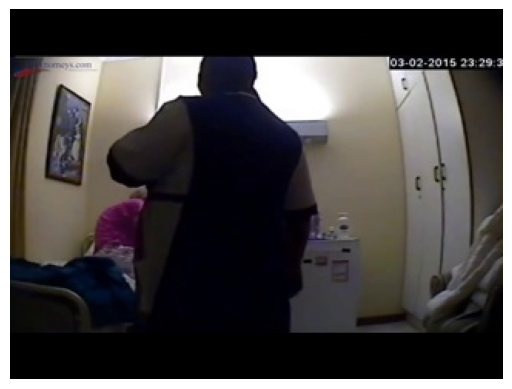

In [34]:
from PIL import Image
import matplotlib.pyplot as plt
import os

img_path = os.path.join(
    OUTPUT_PATH,
    "Test",
    "Abuse",
    os.listdir(os.path.join(OUTPUT_PATH, "Test", "Abuse"))[0]
)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
print(img_path)